In [1]:
import sys
import os 

import numpy as np 
import pandas as pd 

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

sys.path.append(os.path.abspath("../.."))
from src.results_manager import ResultsManager

rm = ResultsManager("svm")

In [2]:
from src.load_processed import load_processed_data

dataset = load_processed_data("../../data/processed/preprocessed.npz")

X_train = dataset["X_train"]
X_test = dataset["X_test"]

y_train = dataset["y_train"]
y_test = dataset["y_test"]

font_test = dataset["font_test"]
italic_test = dataset["italic_test"]
strength_test = dataset["strength_test"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Number of classes:", len(np.unique(y_train)))
print("Data type:", X_train.dtype)

Train shape: (666136, 400)
Test shape: (166534, 400)
Number of classes: 256
Data type: float32


In [3]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LinearSVC(
        C = 1.0,
        max_iter = 1000,
        tol = 1e-2,
        random_state = 42,
        verbose = 1,
        dual = False,
        multi_class = "ovr",
        loss = "squared_hinge"
    ))
])

Uputstvo: 
model mozete trenirati ispocetka (dug proces) ili koristiti vec istreniran i skladisten model. <br>Ukoliko zelite da trenirate model ponovo, izbrisite ga iz results/svm/model.pkl. <br>
Inace, samo pokrenite celiju, ona ce ucitati istrenirani model.

In [4]:
import time 

trained_now = False 
training_time = None

model_loaded = rm.load_model()

if model_loaded is not None: 
    model = model_loaded
    print("Successfully loaded existing model.")
else:
    print("Training model ... ")
    start_time = time.time()

    model.fit(X_train, y_train)

    training_time = time.time() - start_time
    print(f"Training done in {training_time:.2f} seconds")

    # save model using results manager 
    rm.save_model(model)

    trained_now = True 

Path koju gledam: ../../results/svm/model.pkl
Training model ... 
[LibLinear]iter  1 act 6.614e+05 pre 6.612e+05 delta 9.963e-01 f 6.661e+05 |g| 1.328e+06 CG   3
iter  2 act 1.168e+02 pre 1.188e+02 delta 9.963e-01 f 4.769e+03 |g| 6.326e+04 CG   4
iter  3 act 3.175e+01 pre 2.424e+01 delta 9.963e-01 f 4.653e+03 |g| 6.286e+03 CG  28
iter  4 act 2.292e+01 pre 1.739e+01 delta 9.963e-01 f 4.621e+03 |g| 3.153e+03 CG  34
iter  5 act 1.373e+01 pre 1.083e+01 delta 9.963e-01 f 4.598e+03 |g| 2.646e+03 CG  34
iter  6 act 4.733e+00 pre 4.004e+00 delta 9.963e-01 f 4.584e+03 |g| 1.705e+03 CG  32
iter  7 act 7.399e-01 pre 6.869e-01 delta 9.963e-01 f 4.580e+03 |g| 6.662e+02 CG  32
iter  8 act 3.163e-02 pre 3.140e-02 delta 9.963e-01 f 4.579e+03 |g| 1.128e+02 CG  38
iter  1 act 6.590e+05 pre 6.589e+05 delta 9.945e-01 f 6.661e+05 |g| 1.326e+06 CG   3
iter  2 act 1.350e+02 pre 1.390e+02 delta 9.945e-01 f 7.116e+03 |g| 5.939e+04 CG   4
iter  3 act 5.517e+01 pre 4.239e+01 delta 9.945e-01 f 6.981e+03 |g| 1.095

In [5]:

y_pred = model.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average = "macro")
weighted_f1 = f1_score(y_test, y_pred, average = "weighted")

print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Accuracy: 0.41023454669917253
Macro F1: 0.22657656034107512
Weighted F1: 0.35216282989460357


In [7]:
import json 

if training_time is None:
    training_time = -0.1

results = {
    "model": "svm_linear",
    "accuracy": float(accuracy),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "training_time_seconds": float(training_time)
}

# save results in .json file only if model is trained now: 
if trained_now:
    rm.save_metrics(results)


Metrics saved to ../../results/svm/metrics.json


In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(f"Shape: {cm.shape}\n")
print(cm)

Shape: (256, 256)

[[ 10   0   0 ...   0   0   0]
 [  1  15   2 ...   0   0   0]
 [  0   3  49 ...   0   0   0]
 ...
 [  0   0   0 ... 103   0   0]
 [  0   0   0 ...   1  48   4]
 [  0   0   0 ...   0   2  27]]


In [9]:
errors = []

n = cm.shape[0]

for true_class in range(n):
    for pred_class in range(n):
        if true_class != pred_class:            # avoid diag elements 
            count = cm[true_class, pred_class]
            errors.append((true_class, pred_class, count))

errors = sorted(errors, key = lambda x: x[2], reverse = True)

top_errors = errors[:10]

top_errors_readable = []
for true_class, pred_class, count in top_errors:
    label = f"{chr(true_class)} → {chr(pred_class)}"
    top_errors_readable.append((label, count))

errors_df = pd.DataFrame(
    top_errors_readable,
    columns = ["confusion", "count"]
)

rm.save_dataframe(errors_df, "top_confusions")

errors_df

Dataframe saved to ../../results/svm/top_confusions.csv


,confusion,count
0,1 → /,423
1,O → 0,386
2,4 → 9,356
3,I → 1,319
4,2 → 1,288
5,0 → 1,200
6,6 → 1,187
7,D → 0,178
8,U → 0,173
9,8 → 6,168


### Per-class accuracy 

In [10]:
# number of correct classifications per class (diag elements)
correct = np.diag(cm)

# total number of samples per class
total = cm.sum(axis = 1)

# per-class accuracy
per_class_accuracy = correct / total

# ASCII oznake klasa
labels = [f"{i}:{repr(chr(i))}" for i in range(cm.shape[0])]

# dataframe sa rezultatima
per_class_df = pd.DataFrame({
    "character": labels,
    "accuracy": per_class_accuracy,
    "correct": correct,
    "total": total,
    "percentage_%": per_class_accuracy *100
})

# sortiranje po tacnosti
per_class_df = per_class_df.sort_values("accuracy")
rm.save_dataframe(per_class_df, "class_accuracy")

worst_classified = per_class_df.head(10)
rm.save_dataframe(worst_classified, "worst_classified_classes")
print("Worst classified characters:")
print(worst_classified)

best_classified = per_class_df.tail(10)
rm.save_dataframe(best_classified, "best_classified_classes")
print("\nBest classified characters:")
print(best_classified)

Dataframe saved to ../../results/svm/class_accuracy.csv
Dataframe saved to ../../results/svm/worst_classified_classes.csv
Worst classified characters:
      character  accuracy  correct  total  percentage_%
127  127:'\x7f'       0.0        0    254           0.0
153  153:'\x99'       0.0        0    194           0.0
154  154:'\x9a'       0.0        0    189           0.0
155  155:'\x9b'       0.0        0    188           0.0
156  156:'\x9c'       0.0        0    186           0.0
27    27:'\x1b'       0.0        0    374           0.0
158  158:'\x9e'       0.0        0    182           0.0
159  159:'\x9f'       0.0        0    185           0.0
23    23:'\x17'       0.0        0    347           0.0
160  160:'\xa0'       0.0        0    254           0.0
Dataframe saved to ../../results/svm/best_classified_classes.csv

Best classified characters:
   character  accuracy  correct  total  percentage_%
57    57:'9'  0.723475     2823   3902     72.347514
62    62:'>'  0.724416      899  

In [11]:
import warnings
warnings.filterwarnings("ignore")

font_results = []

for font in np.unique(font_test):
    mask = font_test == font

    acc = accuracy_score(
        y_test[mask],
        y_pred[mask]
    )

    font_results.append({
        "font": font,
        "samples": mask.sum(),
        "accuracy": acc
    })


font_df = pd.DataFrame(font_results)
font_df = font_df.sort_values("accuracy", ascending = False)
font_df["accuracy_%"] = (font_df["accuracy"] * 100).round(2)
rm.save_dataframe(font_df, "font_accuracy")

font_df

Dataframe saved to ../../results/svm/font_accuracy.csv


,font,samples,accuracy,accuracy_%
100,NUMERICS,2780,0.964029,96.40
43,E13B,4718,0.951039,95.10
102,OCRB,18706,0.882284,88.23
91,MONEY,1499,0.858572,85.86
101,OCRA,13077,0.826948,82.69
...,...,...,...,...
33,CONSOLAS,1809,0.062465,6.25
18,BUXTON,483,0.055901,5.59
130,SKETCHFLOW,332,0.051205,5.12
126,SERIF,2606,0.047966,4.80


In [12]:
italic_results = []

for value in np.unique(italic_test):
    mask = italic_test == value 

    acc = accuracy_score(
        y_test[mask],
        y_pred[mask]
    )

    italic_results.append({
        "italic": value, 
        "samples": mask.sum(),
        "accuracy": acc
    })

italic_df = pd.DataFrame(italic_results)
italic_df["accuracy_%"] = (italic_df["accuracy"] * 100).round(2)
rm.save_dataframe(italic_df, "italic_accuracy")

italic_df

Dataframe saved to ../../results/svm/italic_accuracy.csv


,italic,samples,accuracy,accuracy_%
0,0,116206,0.510395,51.04
1,1,50328,0.178966,17.90


57.13% karaktera koji nisu italic je klasifikovano tacno  
26.15% karaktera koji jesu italic je klasifikovano tacno

In [13]:
bins = np.linspace(0, 1, 6)   # 0.0, 0.2, 0.4, 0.6, 0.8, 1.0
labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]

strength_results = []

for i in range(len(bins)-1):

    mask = (strength_test >= bins[i]) & (strength_test < bins[i+1])

    samples = mask.sum()
    if samples == 0:
        acc = np.nan
    else: 
        acc = accuracy_score(
            y_test[mask],
            y_pred[mask]
        )


    strength_results.append({
        "strength_range": labels[i],
        "samples": samples,
        "accuracy": acc
    })


strength_df = pd.DataFrame(strength_results)
strength_df["accuracy_%"] = (strength_df["accuracy"] * 100).round(2)

rm.save_dataframe(strength_df, "strength_accuracy")

strength_df

Dataframe saved to ../../results/svm/strength_accuracy.csv


,strength_range,samples,accuracy,accuracy_%
0,0.0-0.2,0,NaN,NaN
1,0.2-0.4,0,NaN,NaN
2,0.4-0.6,114924,0.514218,51.42
3,0.6-0.8,51610,0.178686,17.87
4,0.8-1.0,0,NaN,NaN


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import string


def difference_of_means_image(X, y, class_id):

    class_mask = (y == class_id)

    X_class = X[class_mask]
    X_rest = X[~class_mask]

    mean_class = X_class.mean(axis=0)
    mean_rest = X_rest.mean(axis=0)

    diff = mean_class - mean_rest

    return diff.reshape(20, 20)


def visualize_best_classes(X, y, best_df, rm, n=5):

    class_ids = [int(c.split(":")[0]) for c in best_df["character"].tail(n)]

    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.5))

    for i, class_id in enumerate(class_ids):

        img = difference_of_means_image(X, y, class_id)

        axes[i].imshow(img, cmap="seismic")

        c = chr(class_id)
        if c in string.printable and not c.isspace():
            title = c
        else:
            title = f"ASCII {class_id}"

        axes[i].set_title(title)
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()
    rm.save_plot(plt, "svm_difference_of_means")
   

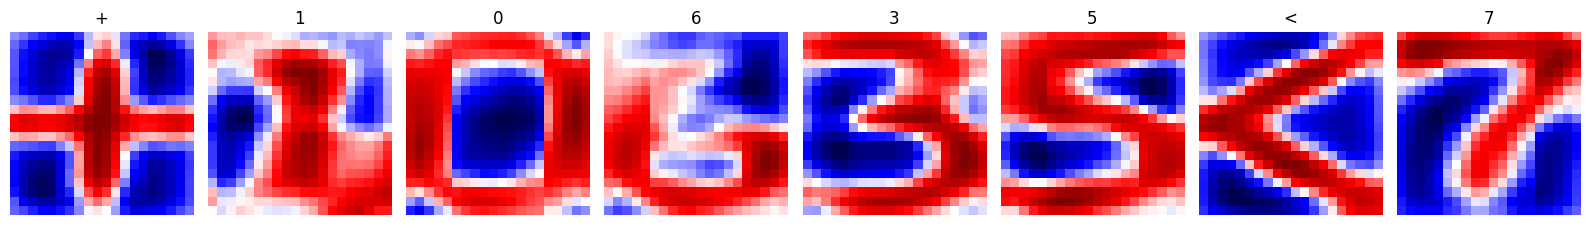

Plot saved to ../../results/svm/svm_difference_of_means.png


In [43]:
visualize_best_classes(
    X_train,
    y_train,
    best_classified,
    rm = rm,
    n = 8
)